In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data Exploration
* Understand our data.
* Let's find missing data and correct or drop it.
* Convert string to integer if needed.

In [2]:
chrun_data= pd.read_csv('customer_churn_dataset-training-master.csv')
chrun_data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
chrun_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [4]:
chrun_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


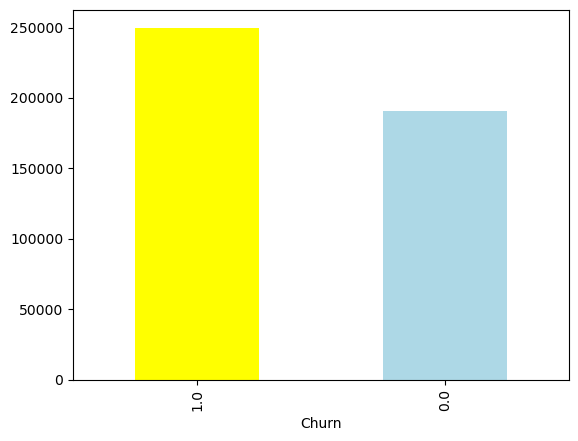

In [5]:
plt.figure()
chrun_data['Churn'].value_counts().plot(kind='bar',color=['yellow','lightblue'])
plt.show()

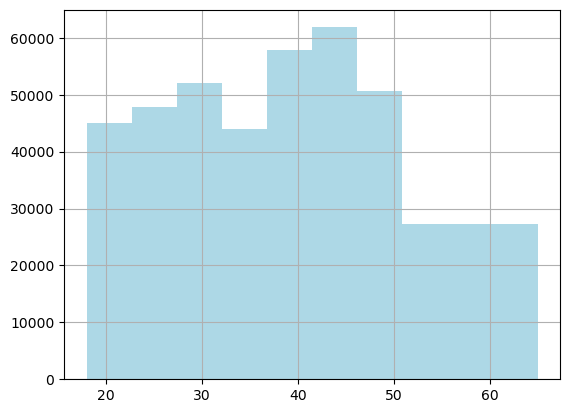

In [6]:
chrun_data['Age'].hist(color='lightblue')
plt.show()

In [7]:
chrun_data.Gender.value_counts()

Gender
Male      250252
Female    190580
Name: count, dtype: int64

In [8]:
chrun_data['Subscription Type'].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [9]:
chrun_data['Contract Length'].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

### Removing missing row

In [10]:
chrun_data.isna().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [11]:
miss=chrun_data[chrun_data['CustomerID'].isna()]
print(miss)

        CustomerID  Age Gender  Tenure  Usage Frequency  Support Calls  \
199295         NaN  NaN    NaN     NaN              NaN            NaN   

        Payment Delay Subscription Type Contract Length  Total Spend  \
199295            NaN               NaN             NaN          NaN   

        Last Interaction  Churn  
199295               NaN    NaN  


In [12]:
chrun_data.iloc[199295]

CustomerID           NaN
Age                  NaN
Gender               NaN
Tenure               NaN
Usage Frequency      NaN
Support Calls        NaN
Payment Delay        NaN
Subscription Type    NaN
Contract Length      NaN
Total Spend          NaN
Last Interaction     NaN
Churn                NaN
Name: 199295, dtype: object

In [13]:
#Dropping the row that has missing value
chrun_data.drop(199295,inplace=True)

In [14]:
chrun_data.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [15]:
churn_temp = chrun_data.copy()
churn_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


### Converting string to integers

In [16]:
churn_temp['Gender'] = churn_temp['Gender'].factorize()[0]
churn_temp['Subscription Type'] = churn_temp['Subscription Type'].factorize()[0]
churn_temp['Contract Length'] = churn_temp['Contract Length'].factorize()[0]

In [17]:
churn_temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  int64  
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  int64  
 8   Contract Length    440832 non-null  int64  
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 43.7 MB


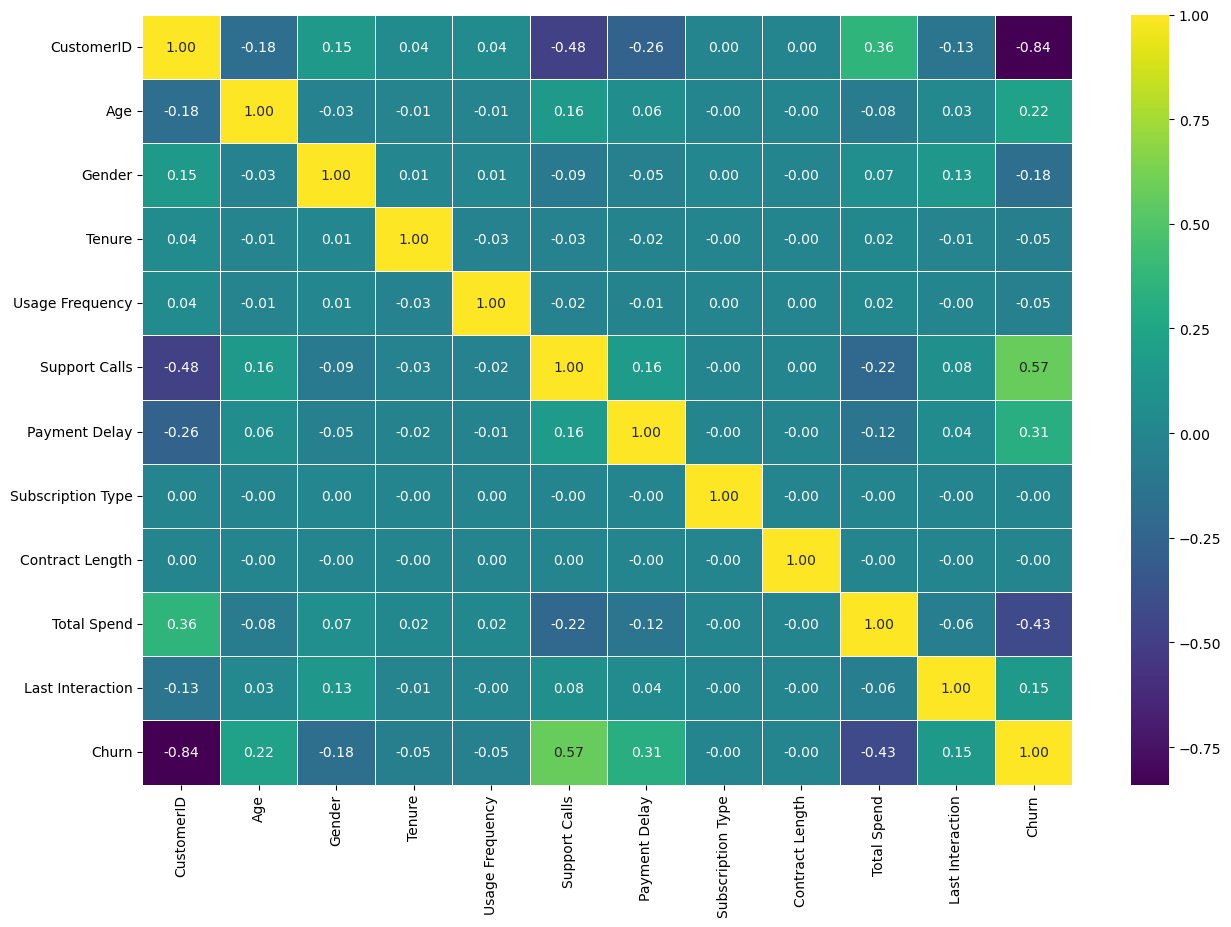

In [18]:
#make correlation matrix
corr_mat= churn_temp.corr()
fig,ax= plt.subplots(figsize=(15,10))
ax= sns.heatmap(corr_mat,annot=True,
                linewidths=0.5,fmt='.2f',
                cmap='viridis')
plt.show();

## Get data ready
We have seperate test dataset. So let's split the training data into training set and validation set

In [19]:
X = churn_temp.drop('Churn',axis=1)
y = churn_temp['Churn']

In [20]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2)

In [21]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((352665, 11), (88167, 11), (352665,), (88167,))

## Choose the right model

In [22]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

In [23]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

### Fit the model to our data

In [24]:
clf.fit(X_train,y_train);

In [25]:
clf.score(X_train,y_train)

1.0

In [26]:
y_preds= clf.predict(X_val)
y_preds

array([0., 1., 1., ..., 0., 0., 0.], shape=(88167,))

### Model evaluation
Let's compare our model's predictions with the actual validation value.

In [27]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, roc_curve,roc_auc_score

In [28]:
#1.Classification Report 
print(classification_report(y_val,y_preds))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38137
         1.0       1.00      1.00      1.00     50030

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



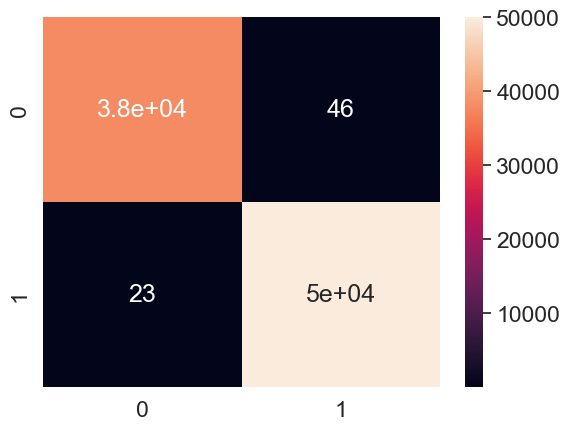

In [29]:
#2.Confusion Matrix
plt.figure()
conf_mat=confusion_matrix(y_val,y_preds)
pd.crosstab(y_val,y_preds,
           rownames=['Actual'],
           colnames=['Predited'])
sns.set(font_scale=1.5)
sns.heatmap(conf_mat,annot=True)
plt.show();

In [30]:
#3.Accuracy
from sklearn.model_selection import cross_val_score 
np.random.seed(18)
cvs = cross_val_score(clf,X,y,cv=5)
np.mean(cvs)
print(f"Customer Churn Accuracy':{np.mean(cvs)*100:.2f}%")

Customer Churn Accuracy':89.87%


In [31]:
#4.ROC Curve
y_probs= clf.predict_proba(X_val)
y_probs[:10]

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.]])

In [32]:
y_probs_positive = y_probs[:,1]
y_probs_positive

array([0., 1., 1., ..., 0., 0., 0.], shape=(88167,))

In [33]:
fpr,tpr,thresholds = roc_curve(y_val,y_probs_positive)
fpr

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.62212549e-05, 2.62212549e-05, 2.62212549e-05, 2.62212549e-05,
       2.62212549e-05, 5.24425099e-05, 7.86637648e-05, 1.04885020e-04,
       1.04885020e-04, 1.04885020e-04, 1.57327530e-04, 1.83548785e-04,
       1.83548785e-04, 1.83548785e-04, 1.83548785e-04, 2.09770040e-04,
       2.09770040e-04, 2.35991295e-04, 2.35991295e-04, 2.35991295e-04,
       2.35991295e-04, 2.35991295e-04, 2.35991295e-04, 2.35991295e-04,
       2.62212549e-04, 2.62212549e-04, 2.62212549e-04, 2.88433804e-04,
       3.40876314e-04, 3.67097569e-04, 3.93318824e-04, 4.19540079e-04,
       4.45761334e-04, 4.71982589e-04, 6.03088864e-04, 6.81752629e-04,
       7.86637648e-04, 8.65301413e-04, 9.17743923e-04, 1.04885020e-03,
       1.20617773e-03, 1.31106275e-03, 1.41594777e-03, 1.52083279e-03,
       1.70438157e-03, 1.83548785e-03, 2.01903663e-03, 2.20258542e-03,
      

In [34]:
def plot_roc(fpr,tpr):
    '''Plots roc curve'''
    plt.figure()
    plt.plot(fpr,tpr,color='yellow',label='ROC')
    plt.plot([0,1],[0,1],color='lightblue',label='Guess',linestyle='--')
    plt.xlabel('False positive')
    plt.ylabel('True positive')
    plt.title('ROC Curve')
    plt.legend()
    plt.show();

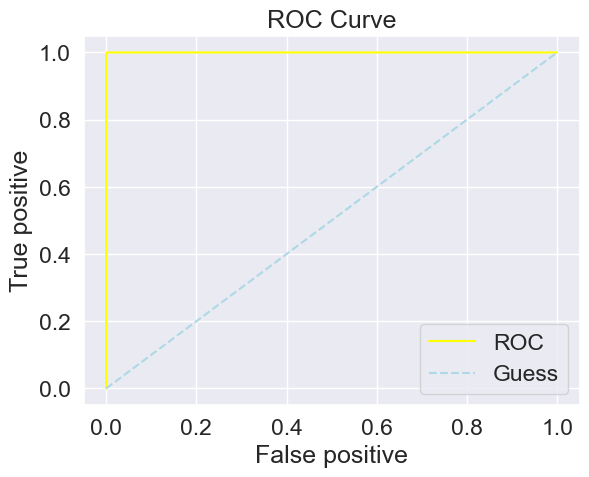

In [35]:
plot_roc(fpr,tpr)

In [36]:
roc_auc_score(y_val,y_probs_positive)

0.999997892289091

## Test data predicition and scoring
We don't need to imporve the model any further. So let's go forward and predict & score our test dataset.


In [37]:
churn_test= pd.read_csv('customer_churn_dataset-testing-master.csv')
churn_test.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [38]:
churn_test['Gender'] = churn_test['Gender'].factorize()[0]
churn_test['Subscription Type'] = churn_test['Subscription Type'].factorize()[0]
churn_test['Contract Length'] = churn_test['Contract Length'].factorize()[0]

In [39]:
churn_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  int64
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  int64
 8   Contract Length    64374 non-null  int64
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(12)
memory usage: 5.9 MB


In [40]:
X_test=churn_test.drop('Churn',axis=1)
y_test=churn_test['Churn']

In [41]:
test_preds= clf.predict(X_test)
test_preds

array([1., 1., 1., ..., 1., 1., 1.], shape=(64374,))

#### Scoring test data

In [42]:
np.random.seed(1)
cvs_test = cross_val_score(clf,X_test,y_test,cv=5)
np.mean(cvs_test)
print(f"Customer Churn Accuracy:{np.mean(cvs_test)*100:.2f}%")

Customer Churn Accuracy:75.56%


In [43]:
print(f"Accuracy of our model:{accuracy_score(y_test,test_preds)*100:.2f}%")

Accuracy of our model:49.46%


#### The model is getting perfect score in validation data set, so it might be overfitting. 
Let's tune our model to get better score in test dataset

In [44]:
cvs_acc=cross_val_score(clf,X_test,y_test,cv=5, scoring='accuracy')
cvs_acc

array([0.64869903, 0.82454369, 0.99976699, 0.99829126, 0.47436694])

In [45]:
cvs_recall=cross_val_score(clf,X_test,y_test,cv=5, scoring='recall')
cvs_recall

array([0.11690441, 0.31169044, 1.        , 1.        , 1.        ])

In [46]:
cvs_f1=cross_val_score(clf,X_test,y_test,cv=5, scoring='f1')
cvs_f1

array([0.18292865, 0.40473404, 0.99975412, 0.99852628, 0.64328287])

In [47]:
cvs_pre=cross_val_score(clf,X_test,y_test,cv=5, scoring='precision')
cvs_pre

array([1.        , 0.99442083, 0.9990172 , 0.99770942, 0.47429416])

<Figure size 640x480 with 0 Axes>

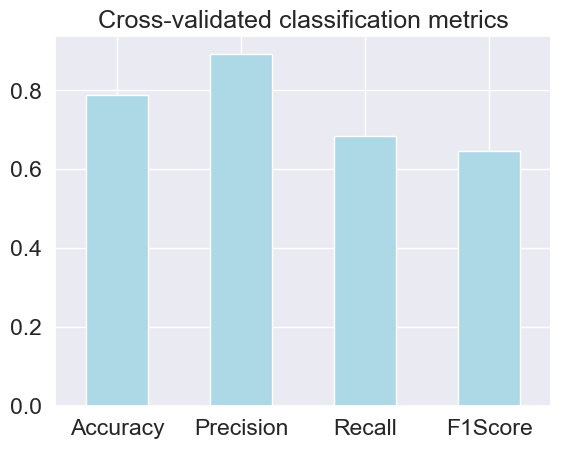

In [48]:
#Visualize cross_val metrics
plt.figure();
cvs_metrics =pd.DataFrame({'Accuracy':np.mean(cvs_acc),
                         'Precision':np.mean(cvs_pre),
                         'Recall':np.mean(cvs_recall),
                         'F1Score':np.mean(cvs_f1)},index=[0])
cvs_metrics.T.plot.bar(title='Cross-validated classification metrics',legend=False,color='lightblue')
plt.xticks(rotation=0)
plt.show();

### Hyperparameter Tunning
Instead of tunning by hand let's use RandomSearchCV method, since iteration is under our control unlike GridSearchCV.

In [49]:
from sklearn.model_selection import RandomizedSearchCV
grid = {'n_estimators':[10,100,500,1000,1200],
       'max_depth':[None,5,10,20,20],
       'max_features':['auto','sqrt'],
       'min_samples_split':[2,4,6],
        'min_samples_leaf':[1,2,4]}
np.random.seed(9)
rs_clf=RandomizedSearchCV(estimator=clf,
                         param_distributions=grid,
                         n_iter=10,cv=5,verbose=2)

Once we fit our model and find thr best parameters. Let's make the following two cells as comands, to avoid re-run in the future

In [50]:
#rs_clf.fit(X_train,y_train)

In [51]:
#rs_clf.best_params_

#### Scoring test data after hyperparameter tunning

In [52]:
clf.score(X_test,y_test)

0.4946251592257744

In [53]:
model = RandomForestClassifier(n_estimators=1500,
                               min_samples_split= 8,
                               min_samples_leaf= 6,
                               max_features= 'sqrt',
                               max_depth= 30)

In [54]:
model.fit(X_train,y_train)

,n_estimators,1500
,criterion,'gini'
,max_depth,30
,min_samples_split,8
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
model.score(X_test,y_test)

0.49386398235312395

### Feature importance

In [56]:
from sklearn.linear_model import LogisticRegression
clfr = LogisticRegression(C=0.20433597178569418,
                        solver='liblinear')

In [57]:
clfr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.20433597178569418
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [58]:
clfr.coef_

array([[-2.33965881e-05,  8.33367415e-02,  4.64086776e-04,
         3.26745654e-02,  2.75884855e-02,  2.24218582e-02,
         4.54867740e-02,  2.20154973e-03,  2.21757888e-03,
        -1.67731290e-04,  3.76456494e-02]])

In [59]:
feature_dict = dict(zip(churn_temp.columns,
                         list(clfr.coef_[0])))
feature_dict

{'CustomerID': np.float64(-2.339658812434366e-05),
 'Age': np.float64(0.0833367415110744),
 'Gender': np.float64(0.00046408677610265155),
 'Tenure': np.float64(0.032674565400180385),
 'Usage Frequency': np.float64(0.02758848547852522),
 'Support Calls': np.float64(0.022421858231868368),
 'Payment Delay': np.float64(0.04548677403580192),
 'Subscription Type': np.float64(0.0022015497280535755),
 'Contract Length': np.float64(0.0022175788778299008),
 'Total Spend': np.float64(-0.00016773128999194334),
 'Last Interaction': np.float64(0.037645649408350114)}

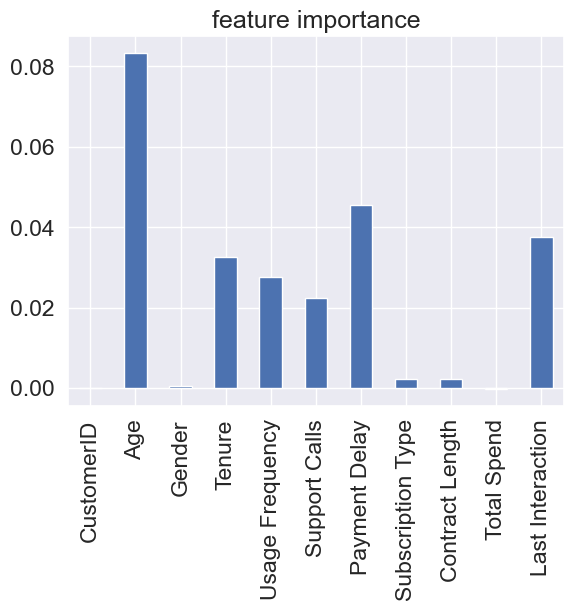

In [60]:
# Visualize feature importance
feature_df = pd.DataFrame (feature_dict,index=[0])
feature_df.T.plot.bar(title='feature importance',legend=False)
plt.show();

### Fitting the data again after dropping unimportant features

In [61]:
churn_dropped = churn_temp.drop(['CustomerID', 'Gender','Total Spend','Subscription Type','Contract Length'], axis=1)
churn_dropped.head() 

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Last Interaction,Churn
0,30.0,39.0,14.0,5.0,18.0,17.0,1.0
1,65.0,49.0,1.0,10.0,8.0,6.0,1.0
2,55.0,14.0,4.0,6.0,18.0,3.0,1.0
3,58.0,38.0,21.0,7.0,7.0,29.0,1.0
4,23.0,32.0,20.0,5.0,8.0,20.0,1.0


In [62]:
X_trainy=churn_dropped.drop('Churn',axis=1)
y_trainy=churn_dropped['Churn'] 

In [63]:
test_dropped = churn_test.drop(['CustomerID', 'Gender','Total Spend','Subscription Type','Contract Length'], axis=1)
test_dropped.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Last Interaction,Churn
0,22,25,14,4,27,9,1
1,41,28,28,7,13,20,0
2,47,27,10,2,29,21,0
3,35,9,12,5,17,18,0
4,53,58,24,9,2,18,0


In [64]:
X_testy=test_dropped.drop('Churn',axis=1)
y_testy=test_dropped['Churn']

In [65]:
model = RandomForestClassifier(n_estimators=1500,
                               min_samples_split= 8,
                               min_samples_leaf= 6,
                               max_features= 'sqrt',
                               max_depth= 30)

In [66]:
model.fit(X_trainy,y_trainy)

,n_estimators,1500
,criterion,'gini'
,max_depth,30
,min_samples_split,8
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
test_predict= model.predict(X_testy)
test_predict

array([1., 1., 1., ..., 1., 1., 1.], shape=(64374,))

In [68]:
model.score(X_testy,y_testy)

0.5802497902880045

In [69]:
clf.fit(X_trainy,y_trainy)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
clf.score(X_testy,y_testy)

0.5795662845248082

## Trying XGBoost Classifier

In [71]:
#!pip install xgboost

In [72]:
# X_train, X_val, y_train, y_val from your prepared data splits
np.random.seed(39)
X_trained,X_valid,y_trained,y_valid = train_test_split(X_trainy,y_trainy,test_size=0.2)

In [73]:
# Calculate the ratio from your training data (X_train, y_train)
# Assuming '1' is the Churn class (positive) and '0' is No-Churn (negative)
negative_count = (y_trainy == 0).sum()
positive_count = (y_trainy == 1).sum()
scale_factor = negative_count / positive_count

In [74]:
from xgboost import XGBClassifier
# 1. Initialize the Model
# Use `use_label_encoder=False` to silence a deprecation warning
# `eval_metric='logloss'` is standard for classification
modelXG = XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss',
    scale_pos_weight=scale_factor,
    use_label_encoder=False,
    random_state=42)

In [75]:
modelXG.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': np.float64(0.7633350533402133),
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None,
 'use_l

In [76]:
# 2. Fit the Model (Train)
# Pass the validation set for early stopping
modelXG.fit(
    X_trained, 
    y_trained,
    eval_set=[(X_valid, y_valid)],
    verbose=False)

C:\Users\USER\Desktop\sample_project\classification-project\env\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:48:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [77]:
# 3. Make Predictions on the Test Set
y_pred_test = modelXG.predict(X_testy)
test_score = accuracy_score(y_testy, y_pred_test)

print(f"XGBoost Test Score: {test_score*100:.4f}%")

XGBoost Test Score: 58.0219%


## Trying Logistic Regressor 

In [78]:
from sklearn.preprocessing import StandardScaler
# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_trainy)
X_test_scaled = scaler.transform(X_testy)

In [79]:
# Initialize the Model
# C is the inverse of regularization strength (smaller C = stronger regularization)
modelLR = LogisticRegression(C=1.0, random_state=42)

In [80]:
#Train the Model
modelLR.fit(X_train_scaled, y_trainy)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [81]:
# Make Predictions
# Predict class labels (0 or 1)
y_pred = modelLR.predict(X_test_scaled) 
y_pred

array([1., 1., 1., ..., 1., 1., 1.], shape=(64374,))

In [82]:
# Predict probabilities (0.0 to 1.0) - essential for ROC-AUC
y_proba = modelLR.predict_proba(X_test_scaled)[:, 1]
y_proba

array([0.8344802 , 0.95181888, 0.86831717, ..., 0.9920191 , 0.98290672,
       0.99718187], shape=(64374,))

In [83]:
modelLR.score(X_test_scaled,y_testy)

0.6062385435113555

## Trying Logistic Regressor hyperparameter tunning

In [93]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
# 1. Initialize the base model
# 'liblinear' solver supports L1 and L2 penalties and is good for small datasets
logreg = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

# 2. Define the Hyperparameter Distribution to sample from
param_dist = {
    # C: Inverse of regularization strength (log-uniform distribution range)
    'C': np.logspace(-4, 2, 100),  
    
    # Penalty: Type of regularization 
    'penalty': ['l1', 'l2'], 
    
    # Class Weight: Important for your imbalanced churn data
    'class_weight': [None, 'balanced'] 
}

# 3. Initialize and Run Randomized Search
# scoring='accuracy' is used here, but ROC-AUC is highly recommended for churn.
random_search = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_dist,
    n_iter=50,             # Number of combinations to test
    scoring='accuracy',    # Use accuracy for now as requested
    cv=5,                  # 5-fold cross-validation
    verbose=0,
    n_jobs=1,
    random_state=42
)

In [94]:
# Fit the search to your SCALED training data
# Ensure X_train_scaled is prepared before this step!
random_search.fit(X_train_scaled, y_trainy) 

,estimator,LogisticRegre...r='liblinear')
,param_distributions,"{'C': array([1.0000...00000000e+02]), 'class_weight': [None, 'balanced'], 'penalty': ['l1', 'l2']}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [95]:
# 4. Access the best model and score
best_logreg_model = random_search.best_estimator_
best_score = random_search.best_score_
best_params = random_search.best_params_

In [96]:
print(best_score)

0.798655727765943


In [97]:
print(best_params)

{'penalty': 'l2', 'class_weight': 'balanced', 'C': np.float64(0.0001519911082952933)}


In [98]:
print(best_logreg_model)

LogisticRegression(C=np.float64(0.0001519911082952933), class_weight='balanced',
                   max_iter=1000, random_state=42, solver='liblinear')


# Final Scores

In [84]:
print(f"Accuracy of our RandomForestClassifier model:{accuracy_score(y_test,test_preds)*100:.4f}%")

Accuracy of our RandomForestClassifier model:49.4625%


In [85]:
print(f"Accuracy of our Tuned RandomForestClassifier model:{accuracy_score(y_testy,test_predict)*100:.4f}%")

Accuracy of our Tuned RandomForestClassifier model:58.0250%


In [86]:
print(f"XGBoost Test Score: {test_score*100:.4f}%")

XGBoost Test Score: 58.0219%


In [87]:
print(f"Accuracy of LogisticRegression model:{accuracy_score(y_testy,y_pred)*100:.4f}%")

Accuracy of LogisticRegression model:60.6239%


In [103]:
print(f"Score of Tuned LogisticRegression model:{best_score*100:.4f}%")

Score of Tuned LogisticRegression model:79.8656%
